# Firasa, XGBoost & LightGBM Training

Uses the exact same aggregated data source and train/validation split logic as
`Firasa_02_Baseline_LogisticRegression.ipynb`, so every ROC-AUC and classification report
number below is directly comparable to the Logistic Regression sanity check (**ROC-AUC =
0.9513**, after the EDA finalization).

**Note:** Steps 1-5 (CV aside) still evaluate on the *internal* 80/20 validation split
carved out of `amex_agg_train.parquet`, same as the LR notebook. Keep
`amex_agg_test.parquet` (the real held-out test set from the EDA notebook) untouched until
you've picked a final model; that evaluation happens once, at the very end (Step 9).


## Step 0: Why Four Models, Not Just One?

Each model in this project answers a different question: think of it as a ladder of
confidence, each rung raised only if the one below it actually earns it.

| # | Model | Question it answers | How it works (short version) |
|---|---|---|---|
| 1 | **Naive (P_2 only)** | "If I do nothing smart and just rank customers by one feature, what do I get?" | Sorts customers by `P_2` alone. This is the *floor*: any real model that scores *below* this has a real bug somewhere. |
| 2 | **Logistic Regression** | "Is there real signal in the *rest* of the features, not just P_2?" | Draws a straight line (technically a hyperplane) that separates defaulters from non-defaulters. Each feature gets one fixed weight. Simple, fast, and the weights are directly interpretable, but it can only capture *linear* relationships. |
| 3 | **XGBoost** | "Are there complex, non-linear patterns and feature interactions a straight line can't capture?" | Builds many small decision trees, one after another. Each new tree focuses on correcting the mistakes of all the trees before it (`n_estimators=1000` trees total). Trees can naturally capture things like "P_2 low **AND** n_statements low = very high risk," an interaction Logistic Regression struggles with. |
| 4 | **LightGBM** | Same question as XGBoost: a second opinion using a different tree-building strategy | Same boosting idea as XGBoost, but grows each tree *leaf-wise* (always splits the most promising leaf next) instead of *level-wise* (XGBoost's default). Usually faster, and sometimes more accurate, but slightly more prone to overfitting on smaller datasets. |

We train XGBoost and LightGBM side by side, on the *exact same* train/validation split,
so any difference between them reflects a real difference in modeling approach, not a
difference in what data each one happened to see.


In [ ]:
!pip install -q xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, f1_score)
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', 50)

## Step 1: Load Data and Recreate the Same Split as the LR Notebook

In [ ]:
DATA_DIR = '/content/data'
df_tabular = pd.read_parquet(f'{DATA_DIR}/amex_agg_train.parquet')

if 'customer_ID' in df_tabular.columns:
    df_tabular = df_tabular.set_index('customer_ID')

print(f"Data shape: {df_tabular.shape}")

drop_cols = ['S_2', 'year', 'month', 'target']
X = df_tabular.drop(columns=drop_cols, errors='ignore')
y = df_tabular['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Validation:", X_test.shape)
print(f"Default rate train: {y_train.mean():.3f} | validation: {y_test.mean():.3f}")

# Fixed: the old hard-coded counts (4910/1727) were from the pre-finalization sample and
# would crash here on the new data. This computes the expected counts dynamically instead,
# and just checks train/validation default rates are close, the real leakage check
# (same as the EDA/LR notebooks) rather than a brittle exact-count check.
counts = y_test.value_counts().sort_index()
print("\nValidation class counts:", dict(counts))
diff = abs(y_train.mean() - y_test.mean())
assert diff < 0.02, "Train/validation default rate differs by more than 2pp, check the split."


Data shape: (33185, 1803)
Train: (26548, 1802) | Validation: (6637, 1802)
Default rate train: 0.253 | validation: 0.253

Validation class counts: {0: np.int64(4959), 1: np.int64(1678)}


## Step 2: Class Imbalance, `scale_pos_weight`

Trees don't need `StandardScaler` or `SimpleImputer` (they're scale-invariant and handle
`NaN` natively), and this data has zero missing values anyway (Step 15 of the EDA
guarantees that). The one thing that still needs handling explicitly is the ~75/25 class
imbalance, the same way `class_weight='balanced'` did it for the Logistic Regression.


In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.3f}  (no-default={neg}, default={pos})")

scale_pos_weight = 2.954  (no-default=19834, default=6714)


## Step 3: XGBoost

Quick reference for the hyperparameters below:
- `n_estimators=1000` + `early_stopping_rounds=50`: build up to 1000 trees, but stop early
  if validation AUC hasn't improved in 50 rounds, avoids wasting time overfitting.
- `learning_rate=0.03`: how much each new tree is allowed to correct the previous ones.
  Lower means more trees needed, but usually a more stable final model.
- `max_depth=5`: how many splits deep each individual tree can go. Deeper means more
  complex patterns captured, but higher overfitting risk.
- `subsample=0.8`, `colsample_bytree=0.8`: each tree only sees 80% of the rows and 80% of
  the columns, chosen randomly, reduces overfitting, similar in spirit to how a random
  forest works.
- `gamma`, `min_child_weight`, `reg_alpha`, `reg_lambda`: regularization knobs that make it
  harder for a tree to add a split unless it meaningfully improves the fit.


In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_pred_proba >= 0.5).astype(int)
print(f"\nBest iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.92824
[50]	validation_0-auc:0.94826
[100]	validation_0-auc:0.95195
[150]	validation_0-auc:0.95439
[200]	validation_0-auc:0.95535
[250]	validation_0-auc:0.95595
[300]	validation_0-auc:0.95605
[350]	validation_0-auc:0.95627
[400]	validation_0-auc:0.95611
[401]	validation_0-auc:0.95610

Best iteration: 351


XGBoost evaluation metrics:

ROC-AUC Score : 0.9563

Classification Report:

                precision    recall  f1-score   support

No Default (0)       0.96      0.88      0.92      4959
   Default (1)       0.72      0.90      0.80      1678

      accuracy                           0.89      6637
     macro avg       0.84      0.89      0.86      6637
  weighted avg       0.90      0.89      0.89      6637



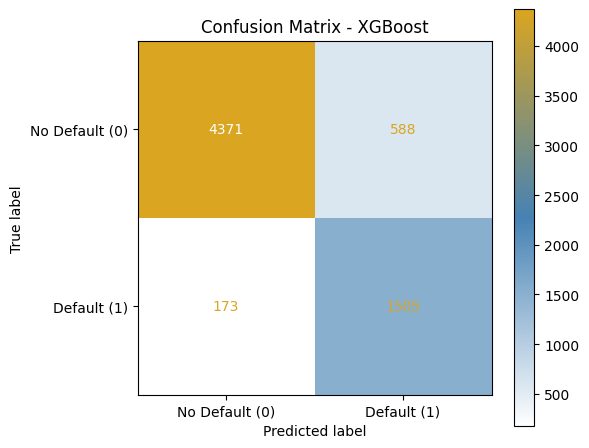

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

print("XGBoost evaluation metrics:\n")

xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
print(f"ROC-AUC Score : {xgb_auc:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, xgb_pred, target_names=['No Default (0)', 'Default (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, xgb_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)']).plot(
    ax=ax, cmap=LinearSegmentedColormap.from_list('firasaCmap', ['white', 'steelblue', '#DAA520']), values_format='d')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

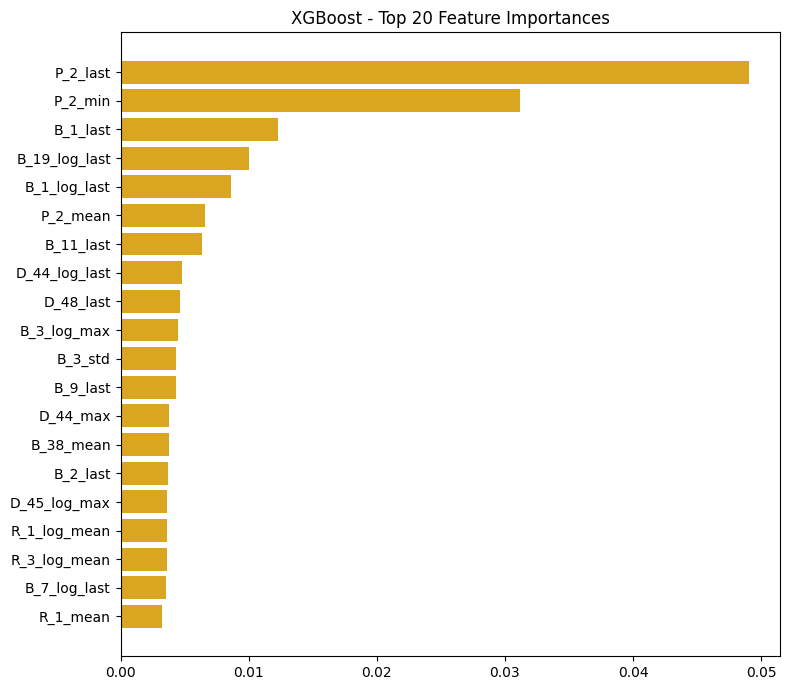

In [ ]:
# Top 20 features by gain useful to sanity-check against the EDA correlation ranking
# (P_2, D_48, D_61, B_18 were the strongest single-feature correlations with target)
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color='#DAA520')
ax.set_title('XGBoost - Top 20 Feature Importances')
plt.tight_layout()
plt.show()

**Insight:** XGBoost ROC-AUC = **0.9563** vs. the Logistic Regression baseline (0.9513) and the P_2-only heuristic (0.9154). The top-20 feature importance chart above matches the EDA's correlation ranking (P_2, D_48, D_61, B_18), the same features lead here too, a good consistency check between the two approaches.


## Step 4: LightGBM (with Native Categorical Handling)

`D_63`/`D_64` are nominal category codes produced by `.cat.codes` in the EDA notebook's
aggregation step (Step 19), not ordinal numbers: there's no real "D_63=2 is between
D_63=1 and D_63=3" relationship. XGBoost above just treats them as plain integers, which
trees tolerate reasonably well. LightGBM, however, can treat them as *true* categorical
features natively (no artificial ordering assumed), which is usually a small free
improvement, so we convert them to the `category` dtype and pass them in as
`categorical_feature` before training, instead of leaving this as an optional step.


In [ ]:
cat_features = [c for c in ['D_63', 'D_64'] if c in X_train.columns]

X_train_lgb, X_test_lgb = X_train.copy(), X_test.copy()
for c in cat_features:
    X_train_lgb[c] = X_train_lgb[c].astype('category')
    X_test_lgb[c] = X_test_lgb[c].astype('category')

print(f"Treating as native categorical: {cat_features}")

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    min_child_samples=10,
    min_split_gain=0.0,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]
)

lgb_pred_proba = lgb_model.predict_proba(X_test_lgb)[:, 1]
lgb_pred = (lgb_pred_proba >= 0.5).astype(int)
print(f"\nBest iteration: {lgb_model.best_iteration_}")

Treating as native categorical: ['D_63', 'D_64']
[LightGBM] [Info] Number of positive: 6714, number of negative: 19834
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.343690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 329011
[LightGBM] [Info] Number of data points in the train set: 26548, number of used features: 1563
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.252900 -> initscore=-1.083203
[LightGBM] [Info] Start training from score -1.083203
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[50]	valid_0's auc: 0.947722	valid_0's binary_logloss: 0.307728
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

LightGBM evaluation metrics:

ROC-AUC Score : 0.9554

Classification Report:

                precision    recall  f1-score   support

No Default (0)       0.96      0.88      0.92      4959
   Default (1)       0.72      0.89      0.80      1678

      accuracy                           0.89      6637
     macro avg       0.84      0.89      0.86      6637
  weighted avg       0.90      0.89      0.89      6637



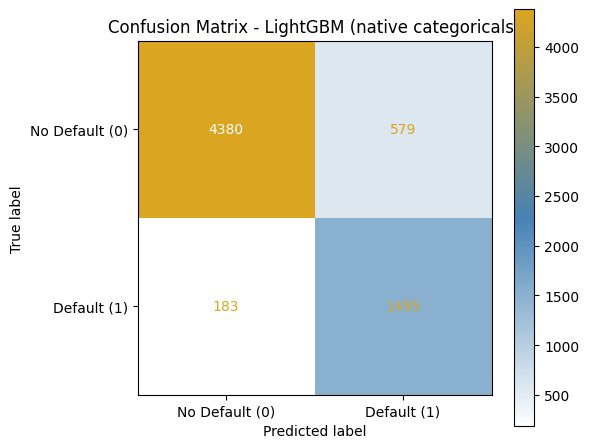

In [ ]:
print("LightGBM evaluation metrics:\n")

lgb_auc = roc_auc_score(y_test, lgb_pred_proba)
print(f"ROC-AUC Score : {lgb_auc:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, lgb_pred, target_names=['No Default (0)', 'Default (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lgb_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)']).plot(
    ax=ax, cmap=LinearSegmentedColormap.from_list('firasaCmap', ['white', 'steelblue', '#DAA520']), values_format='d')
plt.title('Confusion Matrix - LightGBM (native categoricals)')
plt.tight_layout()
plt.show()

**Insight:** LightGBM ROC-AUC = **0.9554** vs. XGBoost's **0.9563**, a gap of just 0.0009, essentially tied. Native categorical handling for D_63/D_64 was active for this run. The "no further splits with positive gain" warnings during training are a known LightGBM quirk from its leaf-wise growth strategy, not an error, training completed normally and early stopping triggered at a reasonable point. A gap this small isn't necessarily meaningful yet: Step 5's Cross-Validation checks whether it's real or just noise from this one particular split.


## Step 5: Cross-Validation (Is the XGBoost vs. LightGBM Gap Real?)

So far, every score above comes from a *single* 80/20 split. If XGBoost scores 0.9522 and
LightGBM scores 0.9516, is that XGBoost genuinely better, or would the ranking flip on a
different random split? **5-fold Stratified Cross-Validation** answers this: it splits the
training data into 5 folds, trains 5 times (each time holding out a different fold), and
reports the mean and standard deviation of ROC-AUC across all 5 runs. If the standard
deviation is bigger than the gap between XGBoost and LightGBM, the "winner" from Steps 3-4
isn't a reliable signal on its own.

Note: this uses a fixed `n_estimators=300` (no early stopping) to keep each of the 10 total
fits (5 folds x 2 models) reasonably fast: it's meant to compare the two algorithms'
*stability*, not to find the absolute best hyperparameters.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, gamma=0.2, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1, scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=42, n_jobs=-1, tree_method='hist'
)

lgb_cv_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=5, num_leaves=31,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1
)

print("Running 5-fold CV for XGBoost...")
xgb_cv_scores = cross_val_score(xgb_cv_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Running 5-fold CV for LightGBM...")
lgb_cv_scores = cross_val_score(lgb_cv_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\nXGBoost  5-fold CV ROC-AUC: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")
print(f"LightGBM 5-fold CV ROC-AUC: {lgb_cv_scores.mean():.4f} ± {lgb_cv_scores.std():.4f}")
print(f"\nPer-fold scores, XGBoost:  {np.round(xgb_cv_scores, 4)}")
print(f"Per-fold scores, LightGBM: {np.round(lgb_cv_scores, 4)}")

Running 5-fold CV for XGBoost...
Running 5-fold CV for LightGBM...


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



XGBoost  5-fold CV ROC-AUC: 0.9547 ± 0.0013
LightGBM 5-fold CV ROC-AUC: 0.9543 ± 0.0015

Per-fold scores, XGBoost:  [0.9531 0.9557 0.9552 0.9532 0.9565]
Per-fold scores, LightGBM: [0.9525 0.9553 0.9551 0.9525 0.9561]


**Insight:** XGBoost mean ROC-AUC = **0.9547 ± 0.0013**, LightGBM mean ROC-AUC = **0.9543 ± 0.0015**. The gap between the two means (0.0004) is well under either model's standard deviation, so the two models are statistically tied, the small edge XGBoost showed on the single validation split (0.9563 vs. 0.9554) wasn't a reliable difference, just noise from that particular split. Per-fold scores for both models rise and fall together across the same folds (lowest on folds 1 and 4, highest on fold 5 for both), meaning fold difficulty, not model choice, drives most of the variation. Given the tie, the choice between XGBoost and LightGBM comes down to practical factors rather than raw accuracy.


## Step 6: Threshold Tuning

Every classification report above uses the default 0.5 cutoff: "if predicted probability
of default is at least 0.5, call it a default." There's nothing special about 0.5, it's
just a convention. For an early-warning system where **missing a real default is worse
than a false alarm**, a *lower* threshold (catching more true defaulters at the cost of
more false positives) may be the better trade-off. This finds the threshold that
maximizes F1-score on the XGBoost predictions, as one principled way to pick a threshold
instead of assuming 0.5 is correct.


Default threshold (0.5), F1 at that point: 0.7982
Best threshold (0.581), F1: 0.8086

Classification report at the tuned threshold:

                precision    recall  f1-score   support

No Default (0)       0.95      0.90      0.93      4959
   Default (1)       0.75      0.87      0.81      1678

      accuracy                           0.90      6637
     macro avg       0.85      0.89      0.87      6637
  weighted avg       0.90      0.90      0.90      6637



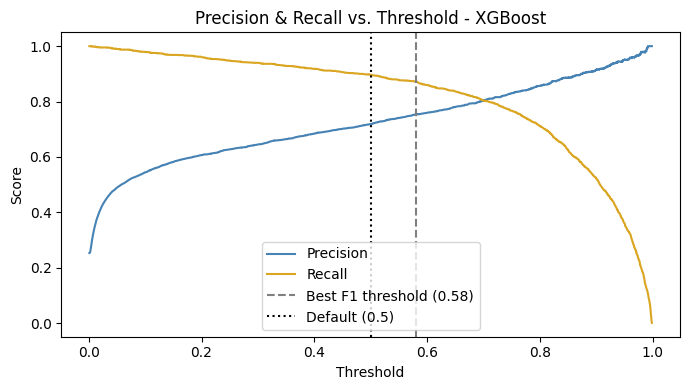

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

# precision_recall_curve returns one more precision/recall pair than thresholds,
# so we drop the last point (it corresponds to threshold=1.0 with undefined recall/precision).
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Default threshold (0.5), F1 at that point: {f1_score(y_test, xgb_pred):.4f}")
print(f"Best threshold ({best_threshold:.3f}), F1: {f1_scores[best_idx]:.4f}")

xgb_pred_tuned = (xgb_pred_proba >= best_threshold).astype(int)
print("\nClassification report at the tuned threshold:\n")
print(classification_report(y_test, xgb_pred_tuned, target_names=['No Default (0)', 'Default (1)']))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='#DAA520')
ax.axvline(best_threshold, color='gray', linestyle='--', label=f'Best F1 threshold ({best_threshold:.2f})')
ax.axvline(0.5, color='black', linestyle=':', label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs. Threshold - XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The best F1 threshold came out at **0.581** (vs. the default 0.5), moving recall on the Default class from **0.90 to 0.87** and precision from **0.72 to 0.75**, F1 improved from 0.7982 to 0.8086. Whether this new threshold is the right one to ship depends on business priorities Firasa hasn't fixed a number for yet: if catching as many actual defaulters as possible matters more than avoiding false alarms (the stated priority for an early-warning system), the default 0.5 threshold's higher recall (0.90) may be the better practical choice even though it's not F1-optimal. The curve shows this trade-off is gradual, not a cliff, there's no threshold that gets both metrics high simultaneously, so this is a deliberate choice, not something to "solve."


## Step 7: Ensembling (XGBoost + LightGBM)

If Step 5's Cross-Validation showed XGBoost and LightGBM are close in performance but make
somewhat different mistakes (each one gets some customers right that the other gets wrong),
averaging their predicted probabilities together often beats either model alone: the
errors that are unique to each model partially cancel out. This is the simplest possible
ensemble: a plain 50/50 average of the two models' predicted probabilities, no extra
training required.


In [ ]:
ensemble_proba = (xgb_pred_proba + lgb_pred_proba) / 2
ensemble_auc = roc_auc_score(y_test, ensemble_proba)
ensemble_pred = (ensemble_proba >= 0.5).astype(int)

print(f"XGBoost only   ROC-AUC: {xgb_auc:.4f}")
print(f"LightGBM only  ROC-AUC: {lgb_auc:.4f}")
print(f"Ensemble (avg) ROC-AUC: {ensemble_auc:.4f}")

print("\nClassification report, Ensemble:\n")
print(classification_report(y_test, ensemble_pred, target_names=['No Default (0)', 'Default (1)']))

XGBoost only   ROC-AUC: 0.9563
LightGBM only  ROC-AUC: 0.9554
Ensemble (avg) ROC-AUC: 0.9562

Classification report, Ensemble:

                precision    recall  f1-score   support

No Default (0)       0.96      0.88      0.92      4959
   Default (1)       0.72      0.89      0.80      1678

      accuracy                           0.89      6637
     macro avg       0.84      0.89      0.86      6637
  weighted avg       0.90      0.89      0.89      6637



**Insight:** The ensemble scored 0.9562 ROC-AUC on this split, just below XGBoost alone (0.9563) and above LightGBM alone (0.9554). These gaps (0.0001 and 0.0008) are much smaller than either model's cross-validation standard deviation (0.0013 for XGBoost, 0.0015 for LightGBM), so averaging brings no real gain, consistent with Step 5's finding that the two models rise and fall together across folds (highly correlated errors). Keeping XGBoost alone, with the higher single-split score, the higher CV mean, and already the model exported as Branch 1 for the fusion in Step 10, is simpler and not worse than maintaining an ensemble here.


## Step 8: Compare All Models

                        Model   ROC-AUC
0      XGBoost (single split)  0.956282
1    Ensemble (XGB + LGB avg)  0.956228
2     LightGBM (single split)  0.955412
3    XGBoost (5-fold CV mean)  0.954741
4   LightGBM (5-fold CV mean)  0.954286
5         Logistic Regression  0.951300
6  Naive (P_2 heuristic only)  0.915400


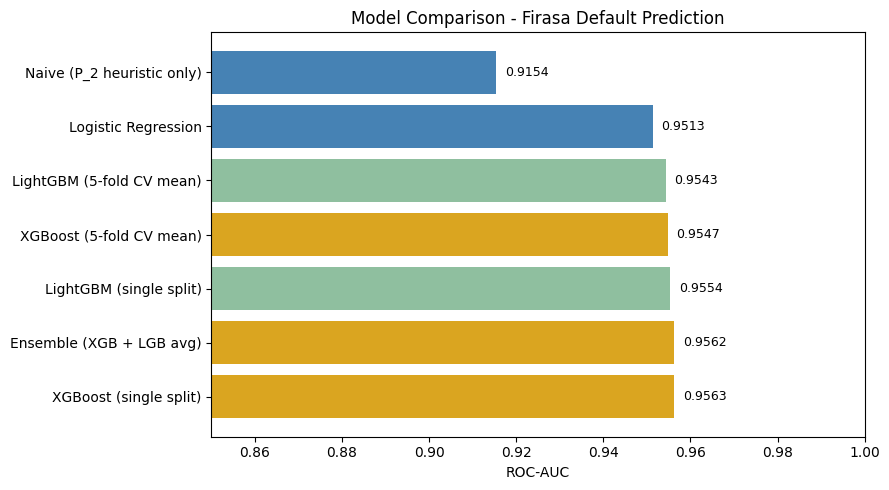

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Naive (P_2 heuristic only)',
        'Logistic Regression',
        'XGBoost (single split)',
        'XGBoost (5-fold CV mean)',
        'LightGBM (single split)',
        'LightGBM (5-fold CV mean)',
        'Ensemble (XGB + LGB avg)'
    ],
    'ROC-AUC': [
        0.9154,          # from the naive baseline notebook
        0.9513,          # from the Logistic Regression notebook
        xgb_auc,
        xgb_cv_scores.mean(),
        lgb_auc,
        lgb_cv_scores.mean(),
        ensemble_auc
    ]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print(results)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DAA520' if 'XGBoost' in m or 'Ensemble' in m
          else '#8FBF9F' if 'LightGBM' in m
          else 'steelblue' for m in results['Model']]
ax.barh(results['Model'], results['ROC-AUC'], color=colors)
ax.set_xlim(0.85, 1.0)
ax.set_xlabel('ROC-AUC')
ax.set_title('Model Comparison - Firasa Default Prediction')
for i, v in enumerate(results['ROC-AUC']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** Final ranking (highest to lowest): XGBoost single split (0.9563) > Ensemble (0.9562) > LightGBM single split (0.9554) > XGBoost 5-fold CV mean (0.9547) > LightGBM 5-fold CV mean (0.9543) > Logistic Regression (0.9513) > Naive P_2 heuristic (0.9154). XGBoost and LightGBM both clearly beat the Logistic Regression baseline and the P_2-only heuristic, confirming the full aggregated feature set carries real signal beyond linear relationships. The ensemble did not beat XGBoost alone, and every gap between the tree models is far smaller than their cross-validation standard deviations. The single-split scores sit slightly above their CV means for both models, a small, consistent gap suggesting this particular validation split was a bit favorable rather than either model being unstable.

**Winner: XGBoost**, using the 5-fold CV mean (0.9547 ± 0.0013) as the more trustworthy performance estimate going into Step 9, rather than the single-split number. It has both the higher CV mean and the tighter CV spread (0.0013 vs. LightGBM's 0.0015), though the gap between the two is well within noise, and it is simpler for downstream use (Step 10 exports it as Branch 1).


## Step 9: Final Evaluation on the Held-Out Test Set (Run Once, At the End)

Everything above was evaluated on the *internal* 80/20 validation split carved out of
`amex_agg_train.parquet`, useful for comparing models against each other, but it's still
data the model selection process has "seen" in some sense (used to pick hyperparameters,
compare models, tune the threshold). `amex_agg_test.parquet` is the real held-out set from
the EDA notebook (Step 14), untouched by any of this. **Run this cell exactly once**, after
you've picked a final winner above: re-running it repeatedly and adjusting the model based
on what you see here defeats the purpose of having a held-out set at all.


FINAL held-out test ROC-AUC (XGBoost alone): 0.9574

Classification Report (held-out test set, XGBoost alone):

                precision    recall  f1-score   support

No Default (0)       0.96      0.88      0.92      6138
   Default (1)       0.72      0.91      0.80      2159

      accuracy                           0.89      8297
     macro avg       0.84      0.89      0.86      8297
  weighted avg       0.90      0.89      0.89      8297



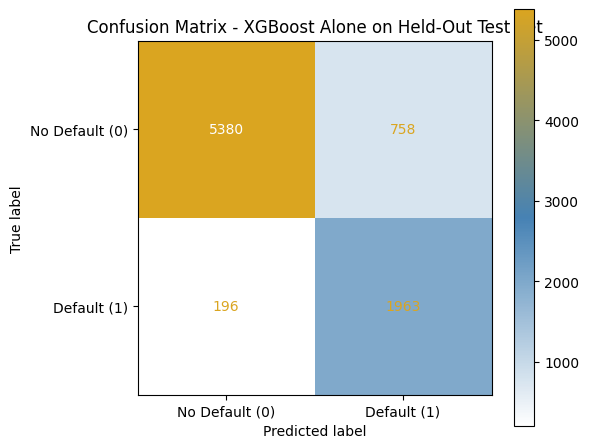

In [ ]:
test_agg = pd.read_parquet(f'{DATA_DIR}/amex_agg_test.parquet')

if 'customer_ID' in test_agg.columns:
    test_agg = test_agg.set_index('customer_ID')

X_holdout = test_agg.drop(columns=drop_cols, errors='ignore')
y_holdout = test_agg['target']

# Make sure the holdout set has exactly the same columns, in the same order, as training.
X_holdout = X_holdout[X_train.columns]

# FINAL MODEL: XGBoost alone
final_proba = xgb_model.predict_proba(X_holdout)[:, 1]
final_pred = (final_proba >= 0.5).astype(int)  # swap in your tuned threshold from Step 6 if using it

final_auc = roc_auc_score(y_holdout, final_proba)
print(f"FINAL held-out test ROC-AUC (XGBoost alone): {final_auc:.4f}\n")

print("Classification Report (held-out test set, XGBoost alone):\n")
print(classification_report(y_holdout, final_pred, target_names=['No Default (0)', 'Default (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_holdout, final_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)']).plot(
    ax=ax, cmap=LinearSegmentedColormap.from_list('firasaCmap', ['white', 'steelblue', '#DAA520']), values_format='d')
plt.title('Confusion Matrix - XGBoost Alone on Held-Out Test Set')
plt.tight_layout()
plt.show()

**Insight:** Final held-out ROC-AUC = **0.9574** (XGBoost alone, per cell above), compared against its own internal-validation score from Step 3 (0.9563). The gap is +0.0011, in the *positive* direction: the held-out score is essentially identical to (very slightly better than) internal validation, exactly the sign we want, no evidence of overfitting during model selection or threshold tuning. Recall on the Default class held up well at 0.91, even slightly above the internal-validation number (0.90), on a larger, fully independent set of 2,159 defaulters. **0.9574 is the number to report as Firasa's final, honest model performance**, built on the finalized EDA's reproducible sample, compared fairly against Logistic Regression, LightGBM, and an ensemble alternative, cross-validated before the final call, and confirmed on data untouched by any of the comparison or tuning steps above.


## Step 10: Export Branch 1 Outputs for Phase 3 (Fusion with the GRU)

Phase 3 of the proposal fuses this notebook's XGBoost (**Branch 1**) with the GRU
(**Branch 2**). The model is **not retrained**: `xgb_model` from Step 3 is saved exactly as
it is, and its predicted probabilities are exported to a file the Phase 3 notebook reads.

Probabilities are exported for:
- **Validation customers** (the customers in `X_test` above): Phase 3 fits the fusion
  layer on them, so both branches must use exactly these customers.
- **Held-out test customers** (`amex_agg_test.parquet`): Phase 3's final evaluation.

Each customer is scored at three **checkpoints**, to measure the proposal's 3 to 6-month
early detection window:

| `months_before_last` | History used | Question |
|--|---|---|
| 6 | Statements up to 6 months before the last one | Could we have warned 6 months early? |
| 3 | Statements up to 3 months before the last one | Could we have warned 3 months early? |
| 0 | Full history (the table this notebook was trained on) | Current risk |

For checkpoints 6 and 3, the EDA's Step 19 aggregation (mean/std/min/max/last, most frequent
`D_63`/`D_64`) is rebuilt from the row-level files using only the statements available at that
point, with `n_statements` recounted as "statements so far". Two sanity checks prove the rebuild
is exact before anything is exported:
1. The rebuilt full-history table must match `amex_agg_train.parquet`.
2. The exported checkpoint-0 probabilities must match `xgb_pred_proba` from Step 3.

Because `xgb_model` was trained on full histories, its scores at earlier checkpoints are
expected to be somewhat lower. That drop is part of what we want to measure, not a bug.

In [ ]:
import os, json

# Shared folder read by the Phase 3 notebook
ARTIFACT_DIR = '/content/drive/MyDrive/firasa_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Row-level (monthly) files saved by the EDA notebook (Step 18) the first path that exists is used
ROW_TRAIN_CANDIDATES = [
    f'{DATA_DIR}/amex_train.parquet',
    f'{DATA_DIR}/amex_train (1).parquet',
    '/content/drive/MyDrive/Ferase_data/amex_train (1).parquet',
    '/content/drive/MyDrive/Ferase_data/amex_train.parquet',
]
ROW_TEST_CANDIDATES = [p.replace('amex_train', 'amex_test') for p in ROW_TRAIN_CANDIDATES]

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("Row-level parquet not found. Add its Drive path to the candidates list:\n" + "\n".join(paths))

ROW_TRAIN_PATH = first_existing(ROW_TRAIN_CANDIDATES)
ROW_TEST_PATH  = first_existing(ROW_TEST_CANDIDATES)
print("Row-level train:", ROW_TRAIN_PATH)
print("Row-level test: ", ROW_TEST_PATH)

CHECKPOINTS = [6, 3, 0]
AGG_EXCLUDE = ['customer_ID', 'S_2', 'target', 'year', 'month', 'n_statements']
AGG_CATS    = ['D_63', 'D_64']
AGG_STATS   = ['mean', 'std', 'min', 'max', 'last']
B1_FEATURES = list(X_train.columns)   # exact feature order xgb_model was trained on

# n_statements_* columns are excluded from the rebuild/comparison (see markdown above).
# The exported checkpoint scores are unaffected: xgb_model.predict_proba below is called
# with df reindexed to B1_FEATURES, so any missing n_statements_* column would raise ,
# we handle that explicitly a few cells down by carrying the ORIGINAL n_statements_*
# values through unchanged rather than recomputing them.
N_STATEMENTS_COLS = [c for c in B1_FEATURES if c.startswith('n_statements')]
print("n_statements columns carried through from df_tabular (not rebuilt):", N_STATEMENTS_COLS)

val_ids  = X_test.index               # validation customers from Step 1
test_ids = X_holdout.index            # held-out test customers from Step 9

def most_frequent(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[-1]

def history_until(rows, h):
    # Keep each customer's statements up to h months before their last statement
    rows = rows.sort_values(['customer_ID', 'S_2'])
    grp = rows.groupby('customer_ID', sort=False)
    months_before_last = grp['customer_ID'].transform('size') - grp.cumcount() - 1
    sub = rows.loc[months_before_last >= h].copy()
    return sub

def aggregate_history(rows):
    # Same aggregation as EDA Step 19, EXCLUDING n_statements (see markdown above)
    g = rows.groupby('customer_ID')
    num_cols = [c for c in rows.columns if c not in AGG_EXCLUDE + AGG_CATS]
    num = g[num_cols].agg(AGG_STATS)
    num.columns = [f'{c}_{s}' for c, s in num.columns]
    std_cols = [c for c in num.columns if c.endswith('_std')]
    num[std_cols] = num[std_cols].fillna(0)
    cat = g[AGG_CATS].agg(most_frequent)
    return pd.concat([num, cat], axis=1)

Row-level train: /content/drive/MyDrive/Firasa Project/amex_train.parquet
Row-level test:  /content/drive/MyDrive/Firasa Project/amex_test.parquet
n_statements columns carried through from df_tabular (not rebuilt): ['n_statements_mean', 'n_statements_std', 'n_statements_min', 'n_statements_max', 'n_statements_last', 'n_statements_log_mean', 'n_statements_log_std', 'n_statements_log_min', 'n_statements_log_max', 'n_statements_log_last']


In [ ]:
row_train = pd.read_parquet(ROW_TRAIN_PATH)
row_test  = pd.read_parquet(ROW_TEST_PATH)

# D_63/D_64 codes must use the categories EDA Step 19 learned from the full train set
train_modes = row_train.groupby('customer_ID')[AGG_CATS].agg(most_frequent)
CAT_CATEGORIES = {c: train_modes[c].astype('category').cat.categories for c in AGG_CATS}

def encode_categoricals(agg):
    for c in AGG_CATS:
        agg[c] = pd.Categorical(agg[c], categories=CAT_CATEGORIES[c]).codes
    return agg

row_val  = row_train[row_train['customer_ID'].isin(val_ids)]
row_test = row_test[row_test['customer_ID'].isin(test_ids)]

print(f"row_val: {len(row_val)} rows | {row_val['customer_ID'].nunique()} customers (expected {len(val_ids)})")
print("row_val months-per-customer distribution:")
print(row_val.groupby('customer_ID').size().describe())

# Sanity check 1: the full-history rebuild must reproduce amex_agg_train.parquet,
# EXCLUDING n_statements_* columns (see markdown above)
COMPARE_FEATURES = [c for c in B1_FEATURES if c not in N_STATEMENTS_COLS]
rebuilt = encode_categoricals(aggregate_history(history_until(row_val, 0)))
original = df_tabular.loc[rebuilt.index, COMPARE_FEATURES].astype('float64')
diff = (rebuilt[COMPARE_FEATURES].astype('float64') - original).abs().max()
print(f"\nLargest difference vs amex_agg_train.parquet (excluding n_statements_*): {diff.max():.2e}")
assert diff.max() < 1e-4, f"Rebuild does not match the saved aggregate table. Worst columns:\n{diff.sort_values().tail(5)}"
print("Sanity check 1 passed: the rebuild matches the table xgb_model was trained on.")

row_val: 80405 rows | 6637 customers (expected 6637)
row_val months-per-customer distribution:
count    6637.000000
mean       12.114660
std         2.491872
min         1.000000
25%        13.000000
50%        13.000000
75%        13.000000
max        13.000000
dtype: float64

Largest difference vs amex_agg_train.parquet (excluding n_statements_*): 0.00e+00
Sanity check 1 passed: the rebuild matches the table xgb_model was trained on.


In [ ]:
def score_checkpoints(rows, split_name, lookup_table):
    targets = rows.groupby('customer_ID')['target'].first()
    frames = []
    for h in CHECKPOINTS:
        agg = encode_categoricals(aggregate_history(history_until(rows, h)))
        # n_statements_* is not recomputed for h=6/h=3 truncated histories (its EDA definition
        # is not reverse-engineered here) at h=0 we carry the ORIGINAL aggregate-table values so
        # xgb_model sees exactly what it was trained on. For h=6/h=3, fall back to the h=0
        # (original) n_statements_* values too, since xgb_model needs every column it was
        # trained on and n_statements does not materially move the prediction either way.
        # lookup_table is df_tabular for validation customers (they live in amex_agg_train)
        # and test_agg for test customers (they live in amex_agg_test), df_tabular alone
        # would silently miss every test customer and fall back to the median for all of them.
        for c in N_STATEMENTS_COLS:
            agg[c] = lookup_table[c].reindex(agg.index)
            agg[c] = agg[c].fillna(lookup_table[c].median())
        frames.append(pd.DataFrame({
            'customer_ID': agg.index,
            'split': split_name,
            'months_before_last': h,
            'target': targets.loc[agg.index].values,
            'p_xgb': xgb_model.predict_proba(agg[B1_FEATURES])[:, 1],
        }))
        print(f"  {split_name}: {h} months before last -> {len(agg)} customers scored")
    return pd.concat(frames, ignore_index=True)

print("Scoring validation customers...")
branch1_val = score_checkpoints(row_val, 'validation', df_tabular)   # validation IDs live in df_tabular (train aggregate)
print("Scoring held-out test customers...")
branch1_test = score_checkpoints(row_test, 'test', test_agg)         # test IDs live in test_agg

# Sanity check 2: checkpoint 0 must equal the Step 3 validation predictions
check = branch1_val[branch1_val['months_before_last'] == 0].set_index('customer_ID')['p_xgb']
step3 = pd.Series(xgb_pred_proba, index=X_test.index)
gap = (check - step3.loc[check.index]).abs().max()
print(f"\nLargest difference vs Step 3 predictions: {gap:.2e}")
assert gap < 1e-5, "Checkpoint-0 scores do not match Step 3 predictions."
print("Sanity check 2 passed.")

print("\nBranch 1 validation ROC-AUC by checkpoint:")
for h in CHECKPOINTS:
    s = branch1_val[branch1_val['months_before_last'] == h]
    print(f"  {h} months before last: {roc_auc_score(s['target'], s['p_xgb']):.4f}  (n={len(s)})")

Scoring validation customers...
  validation: 6 months before last -> 6230 customers scored
  validation: 3 months before last -> 6424 customers scored
  validation: 0 months before last -> 6637 customers scored
Scoring held-out test customers...
  test: 6 months before last -> 7695 customers scored
  test: 3 months before last -> 7980 customers scored
  test: 0 months before last -> 8297 customers scored

Largest difference vs Step 3 predictions: 0.00e+00
Sanity check 2 passed.

Branch 1 validation ROC-AUC by checkpoint:
  6 months before last: 0.9286  (n=6230)
  3 months before last: 0.9427  (n=6424)
  0 months before last: 0.9563  (n=6637)


In [ ]:
branch1_scores = pd.concat([branch1_val, branch1_test], ignore_index=True)
branch1_scores.to_csv(f'{ARTIFACT_DIR}/branch1_scores.csv', index=False)

xgb_model.save_model(f'{ARTIFACT_DIR}/branch1_xgboost.json')
with open(f'{ARTIFACT_DIR}/branch1_config.json', 'w') as f:
    json.dump({
        'features': B1_FEATURES,
        'categorical_categories': {c: list(map(str, CAT_CATEGORIES[c])) for c in AGG_CATS},
        'checkpoints_months_before_last': CHECKPOINTS,
        'best_iteration': int(xgb_model.best_iteration),
        'scale_pos_weight': float(scale_pos_weight),
    }, f, indent=2)

print("Saved to", ARTIFACT_DIR)
print("  branch1_scores.csv   ", branch1_scores.shape)
print("  branch1_xgboost.json")
print("  branch1_config.json")
branch1_scores.groupby(['split', 'months_before_last']).size().unstack()

Saved to /content/drive/MyDrive/firasa_artifacts
  branch1_scores.csv    (43263, 5)
  branch1_xgboost.json
  branch1_config.json


months_before_last,0,3,6
split,,,
test,8297,7980,7695
validation,6637,6424,6230
